In [1]:
!pip install tensorflow
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.0 MB 22.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 21.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/36.3 MB 25.8 MB/s eta 0:00:02
   ----------- ---------------------------- 10.7/36.3 MB 26.0 MB/s eta 0:00:01
   ----------------- ---------------------- 15.7/36.3 MB 25.5 MB/s eta 0:00:01
   ----------------------- ---------------- 21.5/36.3 MB 26.3 MB/s eta 0:00:01
   ------------------------------ --------- 27.3/36.3 MB 26.8 MB/s eta 0:00:01
   ----------------------------------- ---- 32.5/36.3 MB 27.5 MB/s eta 0:00:01
   ----------------------------------- ---- 32.5/36.3 MB 27.5 MB/s eta 0:00:01
   ----------------------------------- ---- 32.5/36.3 MB 27.5 MB/s eta 0:00:01
   ---------------------------------------  36.2/36.3 MB 20.2 MB/s eta 0:00:


[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import glob
import re
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from PIL import Image


import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


In [1]:
import tensorflow as tf
print(f"TensorFlow Version: {tf.__version__}")

# This checks if the GPU was actually utilized
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available:  []


In [2]:
#Root folder where the img/ is locatd
IMAGE_ROOT = r"C:\Users\Wanna\Desktop\Fashion FYP\img"

#CSVs from earlier
IMG_CATEGORY_PATH = r"C:\Users\Wanna\Desktop\Fashion FYP\data\DeepFashion\list_category_img.txt"
CATEGORY_PATH = r"C:\Users\Wanna\Desktop\Fashion FYP\data\DeepFashion\list_category_cloth.txt"


In [3]:
categories = pd.read_csv(
    CATEGORY_PATH,
    sep=r"\s+",
    skiprows=1,
    names=["category_name", "category_type"]
)

#Remove header row artifact
categories = categories[categories["category_name"] != "category_name"].reset_index(drop=True)
categories["category_id"] = categories.index + 1
img_categories = pd.read_csv(
    IMG_CATEGORY_PATH,
    sep=r"\s+",
    skiprows=1,
    names=["image", "category"]
)

img_categories["category"] = pd.to_numeric(img_categories["category"], errors="coerce")
img_categories = img_categories.dropna(subset=["category"])
img_categories["category"] = img_categories["category"].astype(int)

print("Total images:", len(img_categories))


Total images: 289222


C:\Users\Wanna\AppData\Local\Temp\ipykernel_31948\2098777109.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  img_categories = pd.read_csv(


In [4]:
#checking the number of images per category to see the imbalanced distribution of categories within this dataset
counts = img_categories["category"].value_counts().reset_index()
counts.columns = ["category_id", "count"]

counts = counts.merge(
    categories[["category_id", "category_name"]],
    on="category_id"
)

counts.sort_values("count", ascending=False)



,category_id,count,category_name
0,41,72158,Dress
1,18,36887,Tee
2,3,24557,Blouse
3,32,19666,Shorts
4,17,15429,Tank
5,33,14773,Skirt
6,6,13311,Cardigan
7,16,13123,Sweater
8,11,10467,Jacket
9,19,10078,Top


In [5]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"   # gives 2048-d vector
)

embedding_model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

embedding_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [6]:
#img preprocessing step
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img


In [7]:
EMBEDDINGS_DIR = r"C:\Users\Wanna\Desktop\Fashion FYP\embeddings"

In [8]:
def embed_batch(df, batch_index, batch_size, image_root, model):
    start = (batch_index - 1) * batch_size
    end = batch_index * batch_size
    batch_df = df.iloc[start:end]

    embeddings = []
    valid_images = []  # <-- track which images are actually processed

    for i, img_rel_path in enumerate(tqdm(batch_df["image"])):
        full_path = os.path.join(image_root, img_rel_path)

        # Strict check — do NOT silently skip
        if not os.path.exists(full_path):
            raise FileNotFoundError(
                f"Missing image at global index {start + i}: {img_rel_path}"
            )

        img_tensor = load_and_preprocess(full_path)
        emb = model.predict(img_tensor, verbose=0)

        embeddings.append(emb[0])
        valid_images.append(img_rel_path)  # <-- save the path

    embeddings = np.array(embeddings)
    valid_images = np.array(valid_images)

    # Save embeddings
    emb_path = os.path.join(
        EMBEDDINGS_DIR,
        f"embeddings_batch_{batch_index:02d}.npy"
    )
    np.save(emb_path, embeddings)

    # Save image paths
    paths_path = os.path.join(
        EMBEDDINGS_DIR,
        f"image_paths_batch_{batch_index:02d}.npy"
    )
    np.save(paths_path, valid_images)

    print(f"Batch {batch_index} saved → {embeddings.shape}, {valid_images.shape}")


In [9]:
#simplified way to embed images in batches
#embed_batch(img_categories, batch_index=37, batch_size=1222, image_root=IMAGE_ROOT, model=embedding_model)

In [10]:
#testing if embeddings are valid
emb_path = os.path.join(EMBEDDINGS_DIR, "embeddings_batch_31.npy")
paths_path = os.path.join(EMBEDDINGS_DIR, "image_paths_batch_31.npy")

emb = np.load(emb_path)
paths = np.load(paths_path)

print("Embeddings shape:", emb.shape)
print("Paths shape:", paths.shape)
print("Min:", emb.min())
print("Max:", emb.max())
print("Mean:", emb.mean())
print("Embeddings[0] close to Embeddings[1]?", np.allclose(emb[0], emb[1]))

Embeddings shape: (8000, 2048)
Paths shape: (8000,)
Min: 0.0
Max: 31.80743
Mean: 0.40942731
Embeddings[0] close to Embeddings[1]? False


In [11]:
embedding_files = glob.glob(os.path.join(EMBEDDINGS_DIR, "embeddings_batch_*.npy"))

# Extract batch numbers
batch_pattern = re.compile(r"embeddings_batch_(\d+)\.npy")

batches = {}

for file in embedding_files:
    match = batch_pattern.search(os.path.basename(file))
    if match:
        batch_num = int(match.group(1))
        batches[batch_num] = file

# ---- Step 2: Load in correct numeric order ----
all_embeddings = []
all_image_paths = []

for batch_num in sorted(batches.keys()):
    emb_file = batches[batch_num]
    path_file = os.path.join(
        EMBEDDINGS_DIR,
        f"image_paths_batch_{batch_num:02d}.npy"
    )

    if not os.path.exists(path_file):
        raise FileNotFoundError(f"Missing path file for batch {batch_num}")

    emb = np.load(emb_file)
    paths = np.load(path_file)

    if len(emb) != len(paths):
        raise ValueError(f"Mismatch in batch {batch_num}: embeddings vs paths length")

    all_embeddings.append(emb)
    all_image_paths.append(paths)

# ---- Step 3: Concatenate ----
all_embeddings = np.vstack(all_embeddings)
all_image_paths = np.concatenate(all_image_paths)

print("Total embeddings:", all_embeddings.shape)
print("Total image paths:", all_image_paths.shape)

# Build path → embedding index lookup (ONLY ONCE)
path_to_embedding_index = {
    path: idx for idx, path in enumerate(all_image_paths)
}

print("Lookup dictionary built.")


Total embeddings: (289222, 2048)
Total image paths: (289222,)
Lookup dictionary built.


In [26]:
all_embeddings = all_embeddings.astype(np.float32)
all_embeddings = all_embeddings / np.linalg.norm(all_embeddings, axis=1, keepdims=True)

In [33]:
curated_df = pd.read_csv("curated_annotations.csv")

curated_df.head()

,image_path,gender,Weather,Context
0,img/Favorite_Basic_V-Neck_Tee/img_00000013.jpg,M,H,C
1,img/Favorite_Basic_V-Neck_Tee/img_00000044.jpg,M,M,C
2,img/Favorite_Basic_V-Neck_Tee/img_00000031.jpg,M,H,C
3,img/Favorite_Basic_V-Neck_Tee/img_00000003.jpg,M,H,C
4,img/Favorite_Basic_V-Neck_Tee/img_00000010.jpg,M,H,C


In [28]:
def show_image(img_path, title=None):
    plt.figure(figsize=(3, 3))
    img = Image.open(os.path.join(IMAGE_ROOT, img_path))
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

In [29]:
def query_by_image_path(query_path, top_k=1):


    if query_path not in path_to_embedding_index:
        raise ValueError(f"Image path not found in embeddings: {query_path}")

    query_idx = path_to_embedding_index[query_path]

    query_embedding = all_embeddings[query_idx].reshape(1, -1)

    similarities = np.dot(all_embeddings, query_embedding.T).squeeze()

    top_indices = similarities.argsort()[::-1][1:top_k+1]

    print("Query Image:")
    show_image(query_path, "Query")

    print("\nTop Matches:")
    for idx in top_indices:
        similar_path = all_image_paths[idx]
        print(f"Similar image path: {similar_path}")
        show_image(
            all_image_paths[idx],
            f"Similarity: {similarities[idx]:.3f}"
        )

    return top_indices

In [30]:
def query_by_annotation(gender=None, Weather=None, Context=None, top_k=1, n_queries=3):

    filtered_df = curated_df.copy()

    if gender:
        filtered_df = filtered_df[filtered_df["gender"] == gender]

    if Weather:
        filtered_df = filtered_df[filtered_df["Weather"] == Weather]

    if Context:
        filtered_df = filtered_df[filtered_df["Context"] == Context]

    if filtered_df.empty:
        print("No matching items.")
        return

    candidate_paths = filtered_df["image_path"].tolist()

    if len(candidate_paths) < n_queries:
        print("Not enough images to sample multiple queries.")
        n_queries = len(candidate_paths)

    # Pick N UNIQUE random query images
    selected_queries = random.sample(candidate_paths, n_queries)

    print(f"\nShowing {n_queries} random queries for:")
    print(f"Gender={gender}, Weather={Weather}, Context={Context}\n")

    for i, query_path in enumerate(selected_queries, 1):
        print(f"\n--- Query {i} ---")
        print(f"Query path: {query_path}")

        query_by_image_path(query_path, top_k=top_k)

In [36]:
def query_byrandom_baseline(gender=None, Weather=None, Context=None,top_k=1, n_queries=3):
    all_paths = list(path_to_embedding_index.keys())

    if len(all_paths) < n_queries:
        print("Not enough images to sample multiple queries.")
        n_queries = len(all_paths)

    selected_queries = random.sample(all_paths, n_queries)

    print(f"\nShowing {n_queries} random queries (RANDOM BASELINE)\n")

    for i, query_path in enumerate(selected_queries, 1):
        print(f"\n--- Query {i} ---")
        print(f"Query path: {query_path}")

        query_by_image_path(query_path, top_k=top_k)

Not enough images to sample multiple queries.

Showing 1 random queries for:
Gender=M, Weather=H, Context=O


--- Query 1 ---
Query path: img/Pocket_Shirt_Jacket/img_00000037.jpg
Query Image:


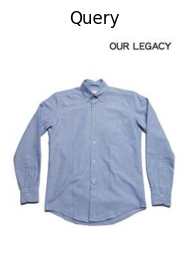


Top Matches:
Similar image path: img/Foulard_Print_Tee/img_00000019.jpg


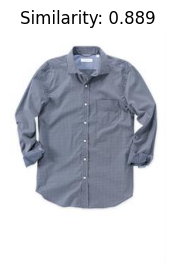

Similar image path: img/Side-Slit_Collared_Blouse/img_00000073.jpg


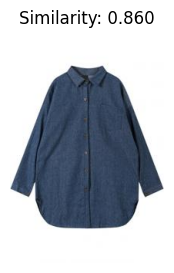

Similar image path: img/Contrast-Trim_Pocket_Tee/img_00000056.jpg


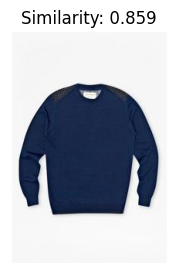

In [35]:
query_by_annotation(gender="M", Weather="H", Context="O",top_k=3)


Showing 3 random queries (RANDOM BASELINE)


--- Query 1 ---
Query path: img/Crisscross_Neckline_Peasant_Blouse/img_00000054.jpg
Query Image:


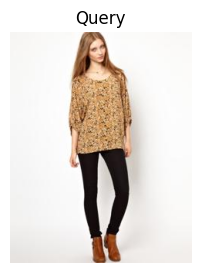


Top Matches:
Similar image path: img/SpongeBob_V-Neck_Tee/img_00000058.jpg


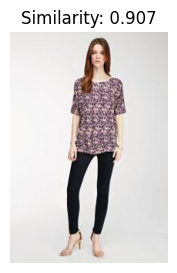

Similar image path: img/Floral_Print_Smock_Dress/img_00000067.jpg


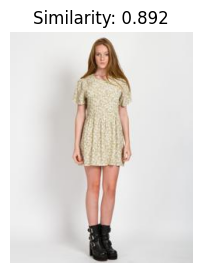

Similar image path: img/Ditsy_Floral_Print_Dress/img_00000022.jpg


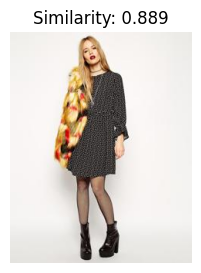


--- Query 2 ---
Query path: img/Floral-Embroidered_Kimono/img_00000031.jpg
Query Image:


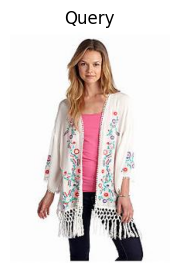


Top Matches:
Similar image path: img/Embroidered_Fringe-Trim_Kimono/img_00000016.jpg


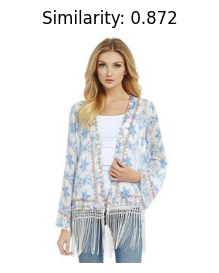

Similar image path: img/Floral_Lace_Kimono/img_00000041.jpg


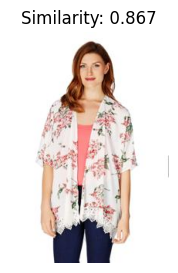

Similar image path: img/Fringed_Shawl_Collar_Cardigan/img_00000034.jpg


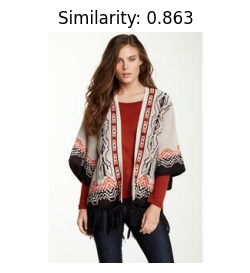


--- Query 3 ---
Query path: img/Longline_Crochet_Overlay_Dress/img_00000020.jpg
Query Image:


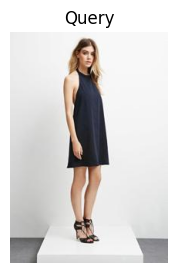


Top Matches:
Similar image path: img/V-Cut_Back_Romper/img_00000015.jpg


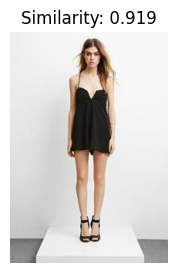

Similar image path: img/Longline_Cutout_Cami_Dress/img_00000006.jpg


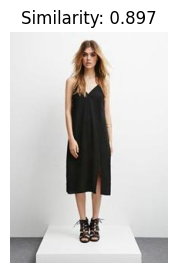

Similar image path: img/Square-Back_Cami_Dress/img_00000020.jpg


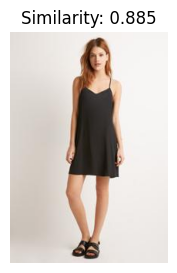

In [49]:
query_byrandom_baseline(gender="F", Weather="H", Context="S", top_k=3, n_queries=3)